# Flux Calibration Sept 19b (Oct 18 flats)

In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy import units as u
from scipy.interpolate import interp1d

from magE.functions import air
from magE.spec.natural_spline import *
from magE.spec.spec_classes import *

In [2]:
# Reduced by BN
# _multispec -> with the -2D flag
# _multi -> without the -2D flag

dataPath = '/home/benjamin/Documents/analogs/calib/mage19b/mage19b18/'

# In this script you should calib

J0136 = MageMultispec.from_fname(dataPath + 'j0136-0037_multi.fits')
J0305 = MageMultispec.from_fname(dataPath + 'j0305+0040_multi.fits')

# Read Feige110 and EG21 1D spectral data
# Feige110 and EG21 multispec from CarPy

feige110 = MageMultispec.from_fname(dataPath + 'feige110_multi.fits')
eg21 = MageMultispec.from_fname(dataPath + 'eg21_multi.fits')

In [3]:
refPath = '/home/benjamin/Documents/analogs/calib/mage19b/'

# feige110 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16), 2 -> flux (mJy)

feige110_ref = pd.read_csv(refPath + 'ffeige110.dat', header=None, 
                           sep='\s+', engine='python')
simple_feige110 = SimpleSpectrum(lda=feige110_ref[0], 
                                 flux=feige110_ref[1]*1e-16)

# eg21 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

eg21_ref = pd.read_csv(refPath + 'feg21.dat', header=None, sep='\s+', 
                          engine='python')
simple_eg21 = SimpleSpectrum(lda=eg21_ref[0], flux=eg21_ref[1]*1e-16)

# Reference Star Spline

In [4]:
x = simple_feige110.lda
y = simple_feige110.flux

mask_feige = (x > air(8852)) + (x > air(7568)) * (x < air(7837)) \
            + (x > air(6810)) * (x < air(6913)) \
            + (x > air(5913)) * (x < air(6485)) \
            + (x > air(5455)) * (x < air(5803)) \
            + (x > air(4910)) * (x < air(5213)) \
            + (x > air(4712)) * (x < air(4791)) \
            + (x > air(4012)) * (x < air(4051)) \
            + (x > air(3919)) * (x < air(3944)) \
            + (x > air(3853)) * (x < air(3858)) \
            + (x > air(3812)) * (x < air(3815)) \
            + (x > air(3784)) * (x < air(3788)) + (x < air(3775))

knots = air(np.array([1164, 1326, 1748, 2500, 3000, 3370,
                  3375, 3521, 3765, 3786, 3813.5, 3855.5, 3925, 4022, 4041,
                  4730, 4750, 4770, 5000, 5150, 5500, 5600, 5700, 5790, 5970,
                  6100, 6200, 6400, 6850, 6900, 7600, 7700, 7800, 9000, 10000,
                  11000, 11090]))

In [5]:
# building spline based model
model_model = get_natural_cubic_spline_model(x=simple_feige110.lda[mask_feige],
                                             y=simple_feige110.flux[mask_feige],
                                            minval=np.min(simple_feige110.lda[mask_feige]),
                                            maxval=np.max(simple_feige110.lda[mask_feige]),
                                            knots=knots)

# getting flux
y_est_custom_model = model_model.predict(simple_feige110.lda)

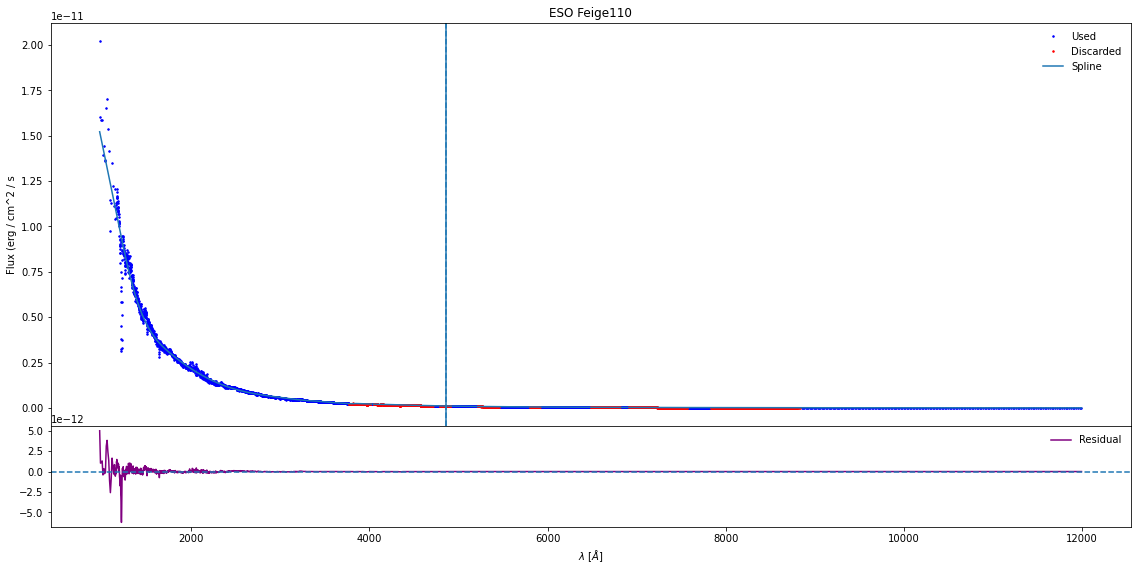

In [6]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_feige110.lda[mask_feige], simple_feige110.flux[mask_feige], ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_feige110.lda[np.logical_not(mask_feige)], simple_feige110.flux[np.logical_not(mask_feige)], ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_feige110.lda, y_est_custom_model, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO Feige110')

ax.axvline(4861.363, ls='--', label='Air')
ax.axvline(4862.721, label='Vacuum')

ax1.plot(x, y - y_est_custom_model, label='Residual', color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]');

In [7]:
reference_flux = interp1d(simple_feige110.lda,
                              model_model.predict(simple_feige110.lda),
                              kind='linear', bounds_error=False,
                              fill_value=np.nan, assume_sorted=True)

# Observed star spline

# Order 6

In [8]:
x6 = feige110.wavelength(6)
y6 = feige110.flux(6)

mask6 = (x6 > 9504.07) * (x6 < 9515.8) \
      + (x6 > 9648.6) * (x6 < 9651.8) \
      + (x6 > 9813)

knots6 = np.array([9510, 9650, 9850, 9900, 10050, 10400, 11000])

In [9]:
model_custom6 = get_natural_cubic_spline_model(x=x6[mask6],
                                               y=y6[mask6], 
                                               minval=np.min(x6),
                                               maxval=np.max(x6),
                                               knots=knots6)
y_est_custom6 = model_custom6.predict(feige110.wavelength(6))

In [10]:
obs_flux6 = spectres(simple_feige110.lda, feige110.wavelength(6), 
                     y_est_custom6, verbose=False)
factor6 = reference_flux(simple_feige110.lda)/obs_flux6

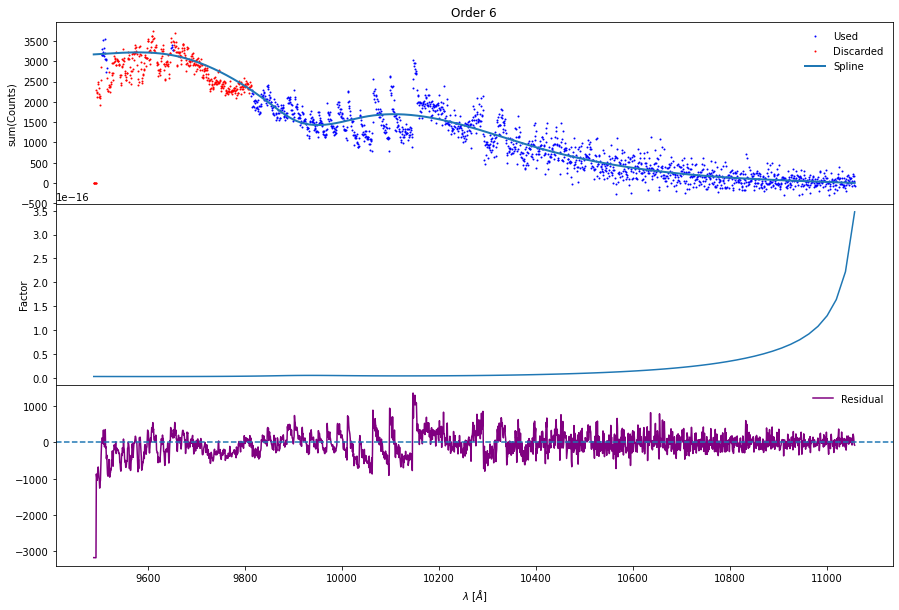

In [11]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x6[mask6], y6[mask6], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(x6[np.logical_not(mask6)], y6[np.logical_not(mask6)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(6), y_est_custom6, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_feige110.lda, factor6)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(6), feige110.flux(6) - y_est_custom6,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 7

In [12]:
y7 = feige110.flux(7)
x7 = feige110.wavelength(7)

mask7 = (x7 > 8170) * (x7 < 8174) \
        + (x7 > 8202) * (x7 < 8207) \
        + (x7 > 8403) * (x7 < 8421) \
        + (x7 > 8475) * (x7 < 8496) \
        + (x7 > 8602) * (x7 < 8619) \
        + (x7 > 8667) * (x7 < 8673) \
        + (x7 > 8750) * (x7 < 8763) \
        + (x7 > 8888) * (x7 < 8895) \
        + (x7 > 8906) * (x7 < 8916) \
        + (x7 > 9046) * (x7 < 9055) \
        + (x7 > 9160) * (x7 < 9165) \
        + (x7 > 9255) * (x7 < 9272) \
        + (x7 > 9447) * (x7 < 9452)

knots7 = np.array([8172, 8205, 8410, 8485, 8610, 8669,
                   8757, 8890, 8910, 9050, 9163, 9265, 9450])

In [13]:
model_custom7 = get_natural_cubic_spline_model(x=x7[mask7],
                                               y=y7[mask7],
                                               minval=np.min(x7),
                                               maxval=np.max(x7),
                                               knots=knots7)
y_est_custom7 = model_custom7.predict(feige110.wavelength(7))

In [14]:
obs_flux7 = spectres(simple_feige110.lda, feige110.wavelength(7),
                     y_est_custom7, verbose=False)
factor7 = reference_flux(simple_feige110.lda)/obs_flux7

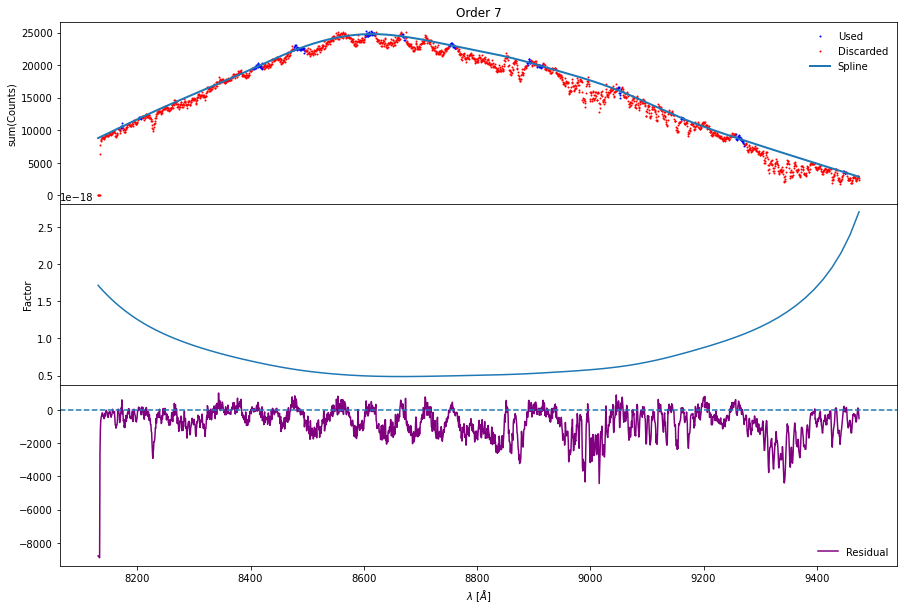

In [15]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x7[mask7], y7[mask7], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(x7[np.logical_not(mask7)], y7[np.logical_not(mask7)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(7), y_est_custom7, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_feige110.lda, factor7)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(7), feige110.flux(7) - y_est_custom7,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 8

In [16]:
y8_1 = feige110.flux(8)[5:827]
x8_1 = feige110.wavelength(8)[5:827]

y8_int = feige110.flux(8)[827:1014]
x8_int = feige110.wavelength(8)[827:1014]

y8_2 = feige110.flux(8)[1014:]
x8_2 = feige110.wavelength(8)[1014:]

mask8_1 = (x8_1 > 7130) * (x8_1 < 7162) \
        + (x8_1 > 7209) * (x8_1 < 7224) \
        + (x8_1 > 7400) * (x8_1 < 7407) \
        + (x8_1 > 7485) * (x8_1 < 7490) \
        + (x8_1 > 7515) * (x8_1 < 7519) \
        + (x8_1 > 7573) * (x8_1 < 7583)

mask8_2 = (x8_2 > 7733) * (x8_2 < 7740) \
        + (x8_2 > 7765) * (x8_2 < 7770) \
        + (x8_2 > 7964) * (x8_2 < 7975) \
        + (x8_2 > 8204) * (x8_2 < 8219) \
        + (x8_2 > 8245) * (x8_2 < 8275)

x8 = feige110.flux(8)
mask8 = (x8 > 7130) * (x8 < 7162) \
        + (x8 > 7209) * (x8 < 7224) \
        + (x8 > 7400) * (x8 < 7407) \
        + (x8 > 7485) * (x8 < 7490) \
        + (x8 > 7515) * (x8 < 7519) \
        + (x8 > 7573) * (x8 < 7583) \
        + (x8 > 7733) * (x8 < 7740) \
        + (x8 > 7765) * (x8 < 7770) \
        + (x8 > 7964) * (x8 < 7975) \
        + (x8 > 8204) * (x8 < 8219) \
        + (x8 > 8245) * (x8 < 8275)

knots8_1 = np.array([7145, 7223, 7404, 7487, 7515, 7579])
knots8_2 = np.array([7737, 7768, 7970, 8210, 8260])

In [17]:
model_custom8_1 = get_natural_cubic_spline_model(x=x8_1[mask8_1],
                                                 y=y8_1[mask8_1],
                                                 minval=np.min(x8_1),
                                                 maxval=np.max(x8_1),
                                                 knots=knots8_1)
y_est_custom8_1 = model_custom8_1.predict(feige110.wavelength(8)[:827])
interp_y8 = interp1d(x8_int, y8_int, kind='linear', bounds_error=False,
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int = interp_y8(x8_int)
model_custom8_2 = get_natural_cubic_spline_model(x=x8_2[mask8_2],
                                                 y=y8_2[mask8_2],
                                                 minval=np.min(x8_2),
                                                 maxval=np.max(x8_2),
                                                 knots=knots8_2)
y_est_custom8_2 = model_custom8_2.predict(x8_2)
y_est_custom8 = np.concatenate((y_est_custom8_1, y_est_custom8_int,
                                y_est_custom8_2))

In [18]:
obs_flux8 = spectres(simple_feige110.lda, feige110.wavelength(8),
                     y_est_custom8, verbose=False)
factor8 = reference_flux(simple_feige110.lda)/obs_flux8

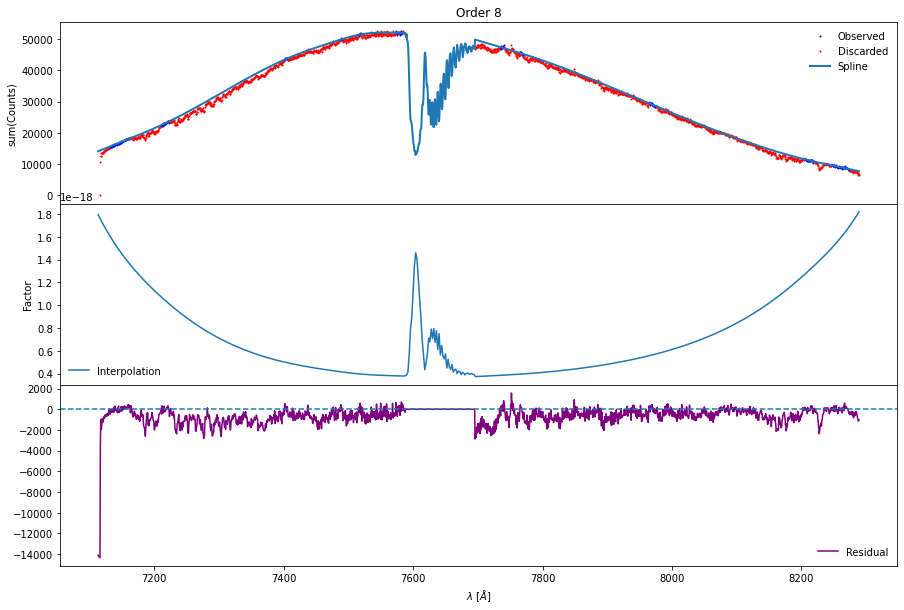

In [19]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x8_1[mask8_1], y8_1[mask8_1],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(x8_2[mask8_2], y8_2[mask8_2],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(x8_1[np.logical_not(mask8_1)], y8_1[np.logical_not(mask8_1)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(x8_2[np.logical_not(mask8_2)], y8_2[np.logical_not(mask8_2)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(feige110.wavelength(8), y_est_custom8, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_feige110.lda, factor8, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(feige110.wavelength(8), feige110.flux(8) - y_est_custom8,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 9

In [20]:
y9_1 = feige110.flux(9)[:1056]
x9_1 = feige110.wavelength(9)[:1056]

y9_int = feige110.flux(9)[1056:1268]
x9_int = feige110.wavelength(9)[1056:1268]

y9_2 = feige110.flux(9)[1268:]
x9_2 = feige110.wavelength(9)[1268:]

mask9_1 = (x9_1 > 6329) * (x9_1 < 6506) \
        + (x9_1 > 6595) * (x9_1 < 6704) \
        + (x9_1 > 6790) * (x9_1 < 6858)

mask9_2 = (x9_2 > 6970) * (x9_2 < 6984) \
        + (x9_2 > 7031) * (x9_2 < 7061) \
        + (x9_2 > 7112) * (x9_2 < 7143) \
        + (x9_2 > 7321) * (x9_2 < 7360)

x9 = feige110.flux(9)
mask9 = (x9 > 6329) * (x9 < 6506) \
      + (x9 > 6595) * (x9 < 6860) \
      + (x9 > 6970) * (x9 < 6984) \
      + (x9 > 7031) * (x9 < 7061) \
      + (x9 > 7112) * (x9 < 7143) \
      + (x9 > 7321) * (x9 < 7360)

knots9_1 = np.array([6338, 6370, 6390, 6420, 6470, 6600, 6700, 6800, 6850])
knots9_2 = np.array([6978, 7045, 7100, 7130, 7350, 7359])

In [21]:
model_custom9_1 = get_natural_cubic_spline_model(x=x9_1[mask9_1],
                                                 y=y9_1[mask9_1],
                                                 minval=np.min(x9_1),
                                                 maxval=np.max(x9_1),
                                                 knots=knots9_1)
y_est_custom9_1 = model_custom9_1.predict(feige110.wavelength(9)[:1056])
interp_y9 = interp1d(x9_int, y9_int, kind='linear', bounds_error=False,
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int = interp_y9(x9_int)
model_custom9_2 = get_natural_cubic_spline_model(x=x9_2[mask9_2],
                                                 y=y9_2[mask9_2],
                                                 minval=np.min(x9_2),
                                                 maxval=np.max(x9_2),
                                                 knots=knots9_2)
y_est_custom9_2 = model_custom9_2.predict(x9_2)
y_est_custom9 = np.concatenate((y_est_custom9_1, y_est_custom9_int,
                                y_est_custom9_2))

In [22]:
obs_flux9 = spectres(simple_feige110.lda, feige110.wavelength(9),
                     y_est_custom9, verbose=False)
factor9 = reference_flux(simple_feige110.lda)/obs_flux9

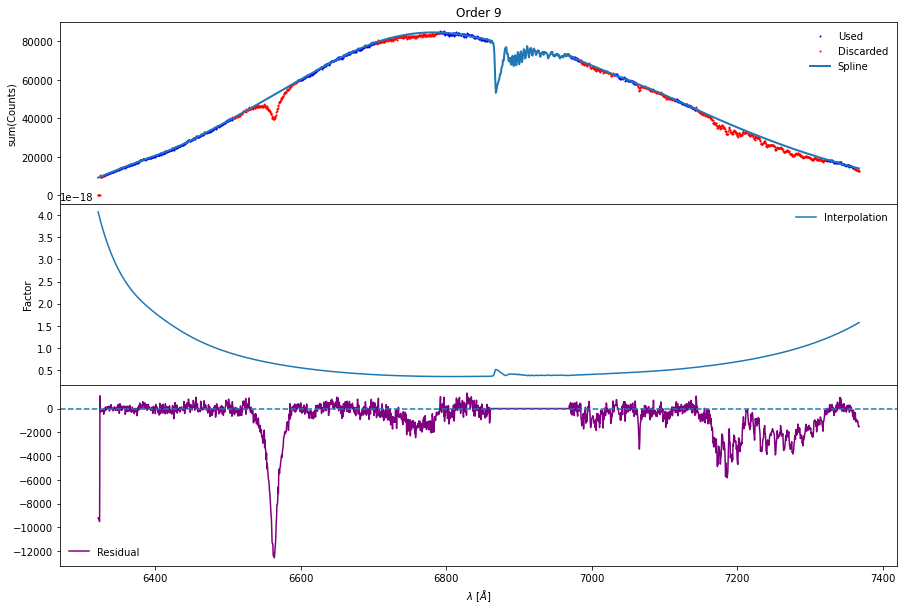

In [23]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x9_1[mask9_1], y9_1[mask9_1],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x9_2[mask9_2], y9_2[mask9_2],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(x9_1[np.logical_not(mask9_1)], y9_1[np.logical_not(mask9_1)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(x9_2[np.logical_not(mask9_2)], y9_2[np.logical_not(mask9_2)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(feige110.wavelength(9), y_est_custom9, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_feige110.lda, factor9, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(feige110.wavelength(9), feige110.flux(9) - y_est_custom9,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 10

In [24]:
y10 = feige110.flux(10)
x10 = feige110.wavelength(10)

mask10 = (x10 > 5691) * (x10 < 5783) \
       + (x10 > 5851) * (x10 < 5865) \
       + (x10 > 5903) * (x10 < 5912) \
       + (x10 > 5965) * (x10 < 5974) \
       + (x10 > 6026) * (x10 < 6033) \
       + (x10 > 6123) * (x10 < 6131) \
       + (x10 > 6263) * (x10 < 6272) \
       + (x10 > 6400) * (x10 < 6415) \
       + (x10 > 6492) * (x10 < 6506) \
       + (x10 > 6580) * (x10 < 6616)

knots10 = np.array([5697, 5750, 5760, 5780, 5858, 5908, 5970, 6029, 6127,
                    6268, 6408, 6499, 6585, 6600])

In [25]:
model_custom10 = get_natural_cubic_spline_model(x=x10[mask10],
                                                y=y10[mask10],
                                                minval=np.min(x10),
                                                maxval=np.max(x10),
                                                knots=knots10)
y_est_custom10 = model_custom10.predict(feige110.wavelength(10))

In [26]:
obs_flux10 = spectres(simple_feige110.lda, feige110.wavelength(10),
                      y_est_custom10, verbose=False)
factor10 = reference_flux(simple_feige110.lda)/obs_flux10

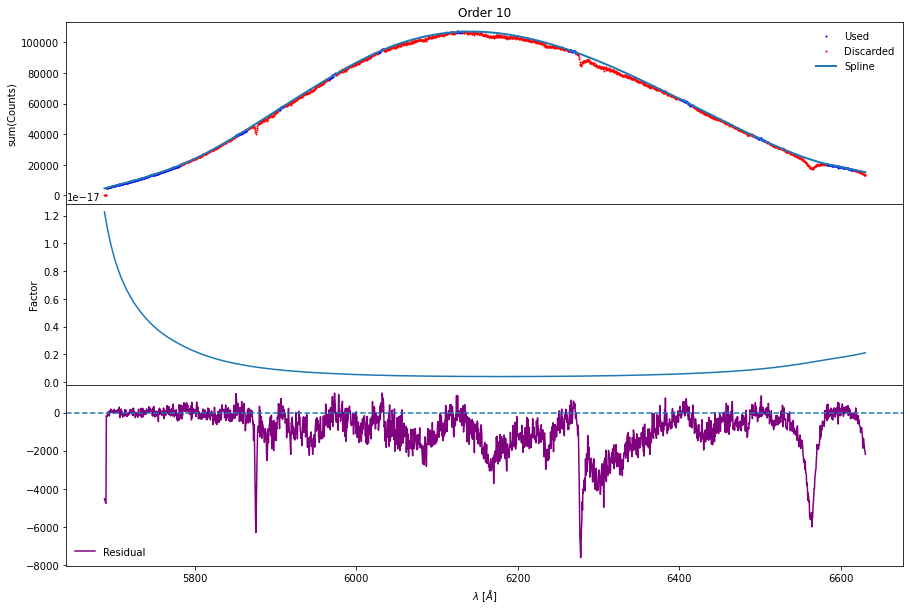

In [27]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x10[mask10], y10[mask10],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x10[np.logical_not(mask10)], y10[np.logical_not(mask10)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(10), y_est_custom10, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_feige110.lda, factor10)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(10), feige110.flux(10) - y_est_custom10,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 11

In [28]:
x11 = feige110.wavelength(11)
y11 = feige110.flux(11)

mask11 = (x11 > 5174) * (x11 < 5398) \
       + (x11 > 5428) * (x11 < 5477) \
       + (x11 > 5528) * (x11 < 5530) \
       + (x11 > 5557) * (x11 < 5561) \
       + (x11 > 5578) * (x11 < 5583) \
       + (x11 > 5640) * (x11 < 5642) \
       + (x11 > 5695) * (x11 < 5700) \
       + (x11 > 5722) * (x11 < 5726) \
       + (x11 > 5819) * (x11 < 5871) \
       + (x11 > 5904)

knots11 = np.array([5183, 5233, 5295, 5335, 5385, 5450, 5529, 5559,
                    5580, 5641, 5698, 5724, 5845, 5908, 5940, 5978, 6021])

In [29]:
model_custom11 = get_natural_cubic_spline_model(x=x11[mask11],
                                                y=y11[mask11],
                                                minval=np.min(x11),
                                                maxval=np.max(x11),
                                                knots=knots11)
y_est_custom11 = model_custom11.predict(feige110.wavelength(11))

In [30]:
obs_flux11 = spectres(simple_feige110.lda, feige110.wavelength(11),
                      y_est_custom11, verbose=False)
factor11 = reference_flux(simple_feige110.lda)/obs_flux11

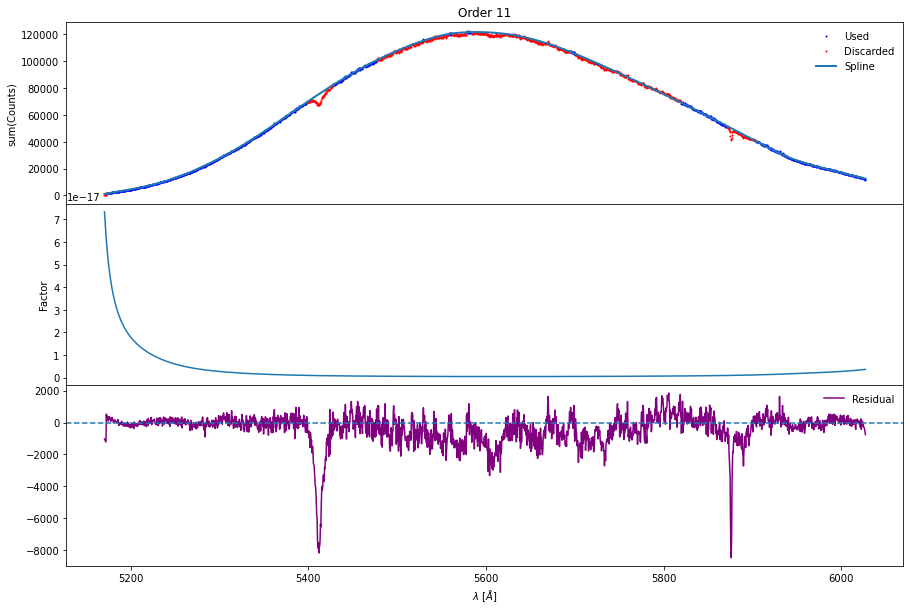

In [31]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x11[mask11], y11[mask11],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x11[np.logical_not(mask11)], y11[np.logical_not(mask11)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(11), y_est_custom11, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_feige110.lda, factor11)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(11), feige110.flux(11) - y_est_custom11,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 12

In [32]:
y12 = feige110.flux(12)
x12 = feige110.wavelength(12)

mask12 = (x12 > 4740) * (x12 < 4841) \
       + (x12 > 4877) * (x12 < 5014) \
       + (x12 > 5075) * (x12 < 5079) \
       + (x12 > 5129) * (x12 < 5134) \
       + (x12 > 5164) * (x12 < 5179) \
       + (x12 > 5265) * (x12 < 5268) \
       + (x12 > 5399) * (x12 < 5402) \
       + (x12 > 5420)

knots12 = np.array([4742, 4754, 4780, 4830, 4916, 5003, 5077,
                    5132, 5170, 5267, 5400, 5440, 5470, 5520])

In [33]:
model_custom12 = get_natural_cubic_spline_model(x=x12[mask12],
                                                y=y12[mask12],
                                                minval=np.min(x12),
                                                maxval=np.max(x12),
                                                knots=knots12)
y_est_custom12 = model_custom12.predict(feige110.wavelength(12))

In [34]:
obs_flux12 = spectres(simple_feige110.lda, feige110.wavelength(12),
                      y_est_custom12, verbose=False)
factor12 = reference_flux(simple_feige110.lda)/obs_flux12

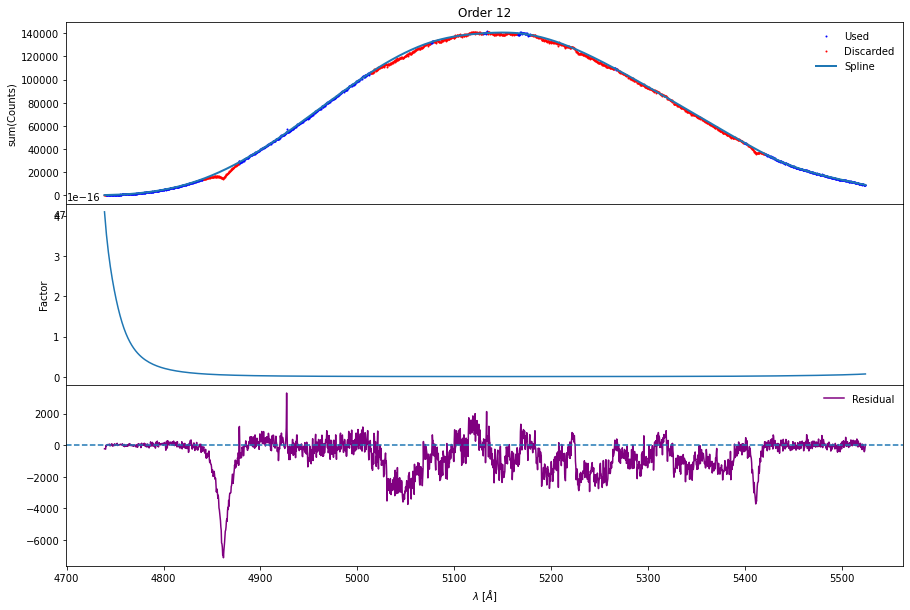

In [35]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x12[mask12], y12[mask12],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x12[np.logical_not(mask12)], y12[np.logical_not(mask12)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(12), y_est_custom12, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_feige110.lda, factor12)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(12), feige110.flux(12) - y_est_custom12,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 13

In [36]:
y13 = feige110.flux(13)
x13 = feige110.wavelength(13)

mask13 = (x13 > 4376) * (x13 < 4468) \
       + (x13 > 4475) * (x13 < 4524) \
       + (x13 > 4559) * (x13 < 4604) \
       + (x13 > 4654) * (x13 < 4668) \
       + (x13 > 4727) * (x13 < 4732) \
       + (x13 > 4781) * (x13 < 4786) \
       + (x13 > 4893)

knots13 = np.array([4379, 4429, 4486, 4520, 4580, 4530, 4730, 4783,
                    4961, 5016, 5051, 5091])

In [37]:
model_custom13 = get_natural_cubic_spline_model(x=x13[mask13],
                                                y=y13[mask13],
                                                minval=np.min(x13),
                                                maxval=np.max(x13),
                                                knots=knots13)
y_est_custom13 = model_custom13.predict(feige110.wavelength(13))

In [38]:
obs_flux13 = spectres(simple_feige110.lda, feige110.wavelength(13),
                      y_est_custom13, verbose=False)
factor13 = reference_flux(simple_feige110.lda)/obs_flux13

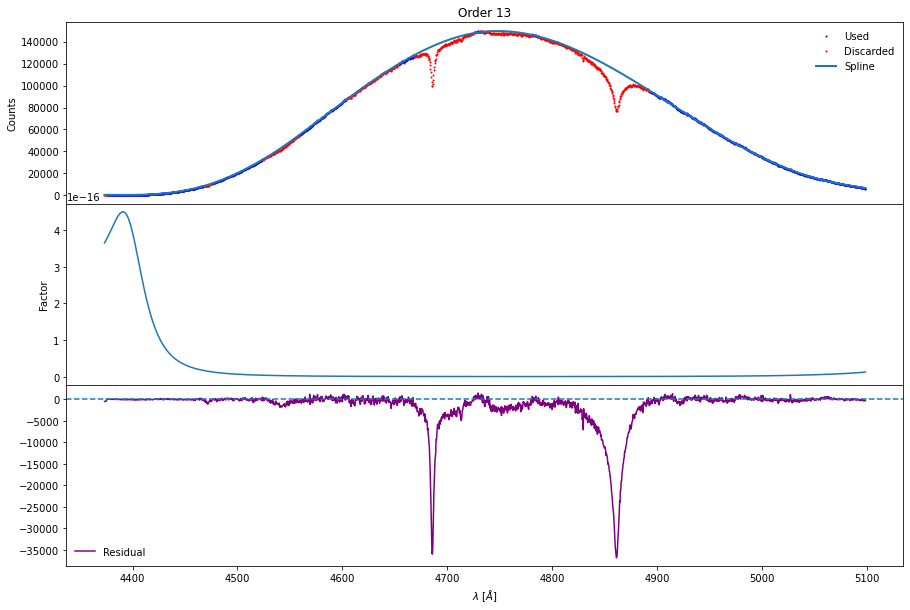

In [39]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x13[mask13], y13[mask13],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x13[np.logical_not(mask13)], y13[np.logical_not(mask13)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(13), y_est_custom13, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_feige110.lda, factor13)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(13), feige110.flux(13) - y_est_custom13,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 14

In [40]:
y14 = feige110.flux(14)
x14 = feige110.wavelength(14)

mask14 = (x14 > 4062) * (x14 < 4300) \
       + (x14 > 4367) * (x14 < 4377) \
       + (x14 > 4404) * (x14 < 4407) \
       + (x14 > 4415) * (x14 < 4421) \
       + (x14 > 4463) * (x14 < 4466) \
       + (x14 > 4488) * (x14 < 4502) \
       + (x14 > 4517) * (x14 < 4532) \
       + (x14 > 4553) * (x14 < 4678) \
       + (x14 > 4692)

knots14 = np.array([4068, 4127, 4142, 4224, 4289, 4372, 4405, 4418,
                    4465, 4495, 4524, 4614, 4646, 4701, 4729])

In [41]:
model_custom14 = get_natural_cubic_spline_model(x=x14[mask14],
                                                y=y14[mask14],
                                                minval=np.min(x14),
                                                maxval=np.max(x14),
                                                knots=knots14)
y_est_custom14 = model_custom14.predict(feige110.wavelength(14))

In [42]:
obs_flux14 = spectres(simple_feige110.lda, feige110.wavelength(14),
                      y_est_custom14, verbose=False)
factor14 = reference_flux(simple_feige110.lda)/obs_flux14

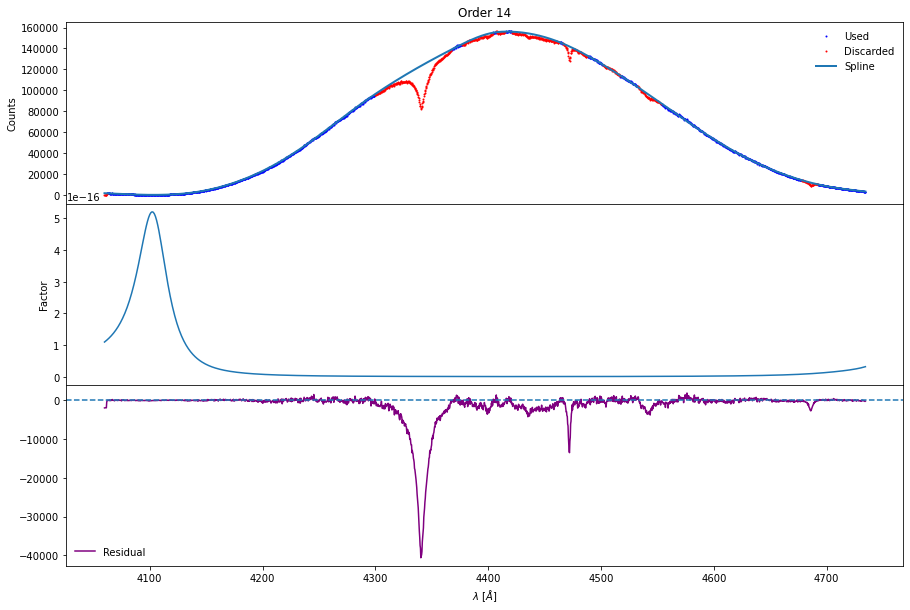

In [43]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x14[mask14], y14[mask14],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x14[np.logical_not(mask14)], y14[np.logical_not(mask14)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(14), y_est_custom14, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_feige110.lda, factor14)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(14), feige110.flux(14) - y_est_custom14,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 15

In [44]:
y15 = feige110.flux(15)
x15 = feige110.wavelength(15)

mask15 = (x15 > 3790) * (x15 < 3932) \
       + (x15 > 3935) * (x15 < 3951) \
       + (x15 > 3989) * (x15 < 4020) \
       + (x15 > 4046) * (x15 < 4053) \
       + (x15 > 4061) * (x15 < 4068) \
       + (x15 > 4073) * (x15 < 4076) \
       + (x15 > 4126) * (x15 < 4128) \
       + (x15 > 4135) * (x15 < 4137) \
       + (x15 > 4157) * (x15 < 4161) \
       + (x15 > 4180) * (x15 < 4187) \
       + (x15 > 4209) * (x15 < 4319) \
       + (x15 > 4357)

knots15 = np.array([3797, 3840, 3876, 3891, 3925, 3946, 4007, 4049,
                    4065, 4074, 4127, 4136, 4159, 4183, 4242, 4303,
                    4367, 4402])

In [45]:
model_custom15 = get_natural_cubic_spline_model(x=x15[mask15],
                                                y=y15[mask15],
                                                minval=np.min(x15),
                                                maxval=np.max(x15),
                                                knots=knots15)
y_est_custom15 = model_custom15.predict(feige110.wavelength(15))

In [46]:
obs_flux15 = spectres(simple_feige110.lda, feige110.wavelength(15),
                      y_est_custom15, verbose=False)
factor15 = reference_flux(simple_feige110.lda)/obs_flux15

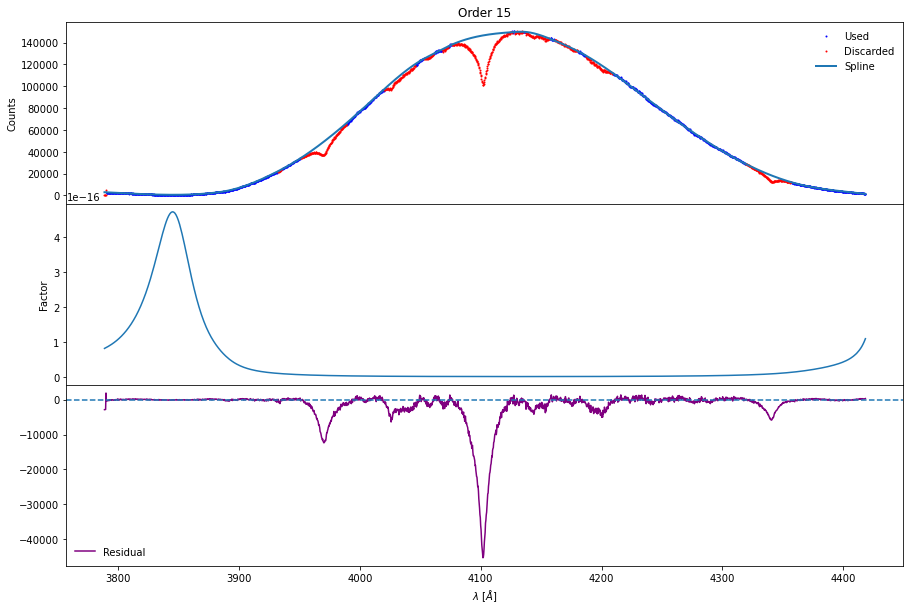

In [47]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x15[mask15], y15[mask15],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x15[np.logical_not(mask15)], y15[np.logical_not(mask15)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(15), y_est_custom15, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_feige110.lda, factor15)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(15), feige110.flux(15) - y_est_custom15,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 16

In [48]:
y16 = feige110.flux(16)
x16 = feige110.wavelength(16)

mask16 = (x16 > 3552) * (x16 < 3706) \
       + (x16 > 3766) * (x16 < 3768) \
       + (x16 > 3810) * (x16 < 3816) \
       + (x16 > 3861) * (x16 < 3865) \
       + (x16 > 3912) * (x16 < 3931) \
       + (x16 > 3938) * (x16 < 3942) \
       + (x16 > 4016) * (x16 < 4020) \
       + (x16 > 4031) * (x16 < 4089) \
       + (x16 > 4110)

knots16 = np.array([3554, 3561, 3618, 3677, 3767, 3813, 3863, 3915,
                    3929, 3940, 4006, 4040, 4075, 4120, 4138])

In [49]:
model_custom16 = get_natural_cubic_spline_model(x=x16[mask16],
                                                y=y16[mask16],
                                                minval=np.min(x16),
                                                maxval=np.max(x16),
                                                knots=knots16)
y_est_custom16 = model_custom16.predict(feige110.wavelength(16))

In [50]:
obs_flux16 = spectres(simple_feige110.lda, feige110.wavelength(16),
                      y_est_custom16, verbose=False)
factor16 = reference_flux(simple_feige110.lda)/obs_flux16

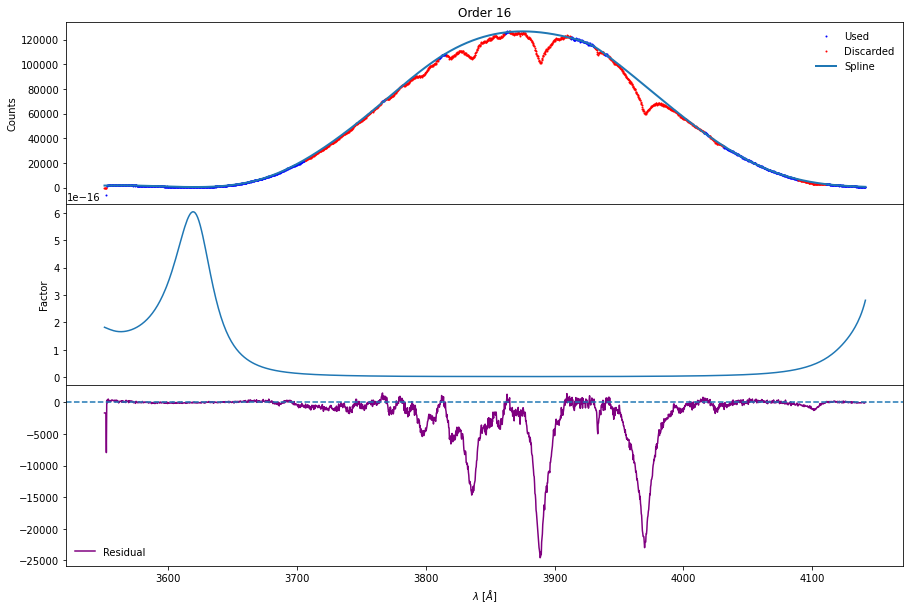

In [51]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x16[mask16], y16[mask16],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x16[np.logical_not(mask16)], y16[np.logical_not(mask16)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(16), y_est_custom16, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_feige110.lda, factor16)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(16), feige110.flux(16) - y_est_custom16,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 17

In [52]:
x17 = feige110.wavelength(17)
y17 = feige110.flux(17)

mask17 = (x17 > 3342) * (x17 < 3483) \
       + (x17 > 3535) * (x17 < 3548) \
       + (x17 > 3555) * (x17 < 3561) \
       + (x17 > 3607) * (x17 < 3610) \
       + (x17 > 3649) * (x17 < 3653) \
       + (x17 > 3663) * (x17 < 3666) \
       + (x17 > 3684) * (x17 < 3690) \
       + (x17 > 3709) * (x17 < 3711) \
       + (x17 > 3759) * (x17 < 3765) \
       + (x17 > 3777) * (x17 < 3784) \
       + (x17 > 3808) * (x17 < 3814) \
       + (x17 > 3846)

knots17 = np.array([3346, 3368, 3392, 3419, 3461, 3541, 3558, 3609,
                    3651, 3665, 3687, 3710, 3762, 3780, 3811, 3856,
                    3892])

In [53]:
model_custom17 = get_natural_cubic_spline_model(x=x17[mask17],
                                                y=y17[mask17],
                                                minval=np.min(x17),
                                                maxval=np.max(x17),
                                                knots=knots17)
y_est_custom17 = model_custom17.predict(feige110.wavelength(17))

In [54]:
obs_flux17 = spectres(simple_feige110.lda, feige110.wavelength(17),
                      y_est_custom17, verbose=False)
factor17 = reference_flux(simple_feige110.lda)/obs_flux17

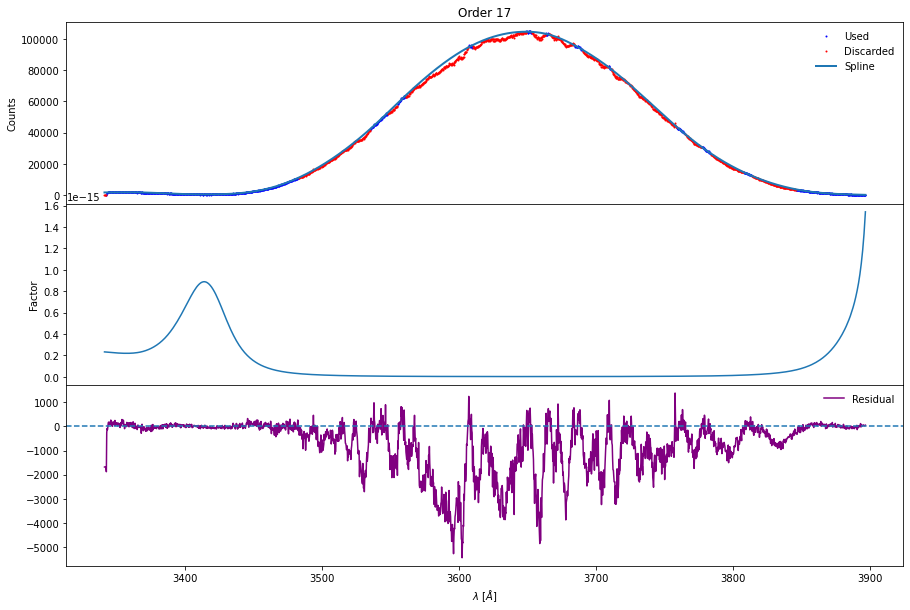

In [55]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x17[mask17], y17[mask17],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x17[np.logical_not(mask17)], y17[np.logical_not(mask17)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(17), y_est_custom17, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_feige110.lda, factor17)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(17), feige110.flux(17) - y_est_custom17,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 18

In [56]:
x18 = feige110.wavelength(18)
y18 = feige110.flux(18)

mask18 = (x18 > 3157) * (x18 < 3191) \
       + (x18 > 3210) * (x18 < 3225) \
       + (x18 > 3260) * (x18 < 3266) \
       + (x18 > 3292) * (x18 < 3299) \
       + (x18 > 3324) * (x18 < 3326) \
       + (x18 > 3351) * (x18 < 3357) \
       + (x18 > 3384) * (x18 < 3387) \
       + (x18 > 3419) * (x18 < 3423) \
       + (x18 > 3431) * (x18 < 3434) \
       + (x18 > 3450) * (x18 < 3454) \
       + (x18 > 3475) * (x18 < 3480) \
       + (x18 > 3490) * (x18 < 3493) \
       + (x18 > 3503.4) * (x18 < 3505.5) \
       + (x18 > 3512.5) * (x18 < 3514.3) \
       + (x18 > 3543) * (x18 < 3546) \
       + (x18 > 3557) * (x18 < 3679.5)

knots18 = np.array([3159, 3170, 3182, 3231, 3263, 3295, 3325, 3354,
                    3386, 3421, 3432, 3452, 3477.5, 3491.5, 3504.5,
                    3513.5, 3545, 3575, 3616, 3651, 3675])

In [57]:
model_custom18 = get_natural_cubic_spline_model(x=x18[mask18],
                                                y=y18[mask18],
                                                minval=np.min(x18),
                                                maxval=np.max(x18),
                                                knots=knots18)
y_est_custom18 = model_custom18.predict(feige110.wavelength(18))

In [58]:
obs_flux18 = spectres(simple_feige110.lda, feige110.wavelength(18),
                      y_est_custom18, verbose=False)
factor18 = reference_flux(simple_feige110.lda)/obs_flux18

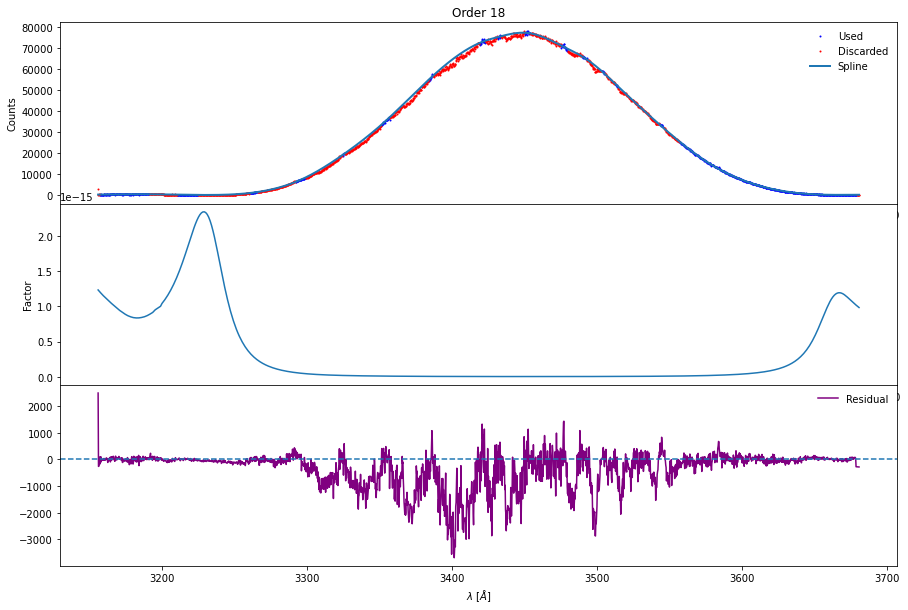

In [59]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x18[mask18], y18[mask18],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x18[np.logical_not(mask18)], y18[np.logical_not(mask18)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(18), y_est_custom18, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_feige110.lda, factor18)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(18), feige110.flux(18) - y_est_custom18,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 19

In [60]:
y19 = feige110.flux(19)
x19 = feige110.wavelength(19)

mask19 = (x19 > 3063) * (x19 < 3118) \
       + (x19 > 3142) * (x19 < 3151) \
       + (x19 > 3182) * (x19 < 3193) \
       + (x19 > 3208) * (x19 < 3212) \
       + (x19 > 3236) * (x19 < 3239) \
       + (x19 > 3266) * (x19 < 3268) \
       + (x19 > 3288) * (x19 < 3293) \
       + (x19 > 3322) * (x19 < 3324) \
       + (x19 > 3356) * (x19 < 3362) \
       + (x19 > 3378) * (x19 < 3476)

knots19 = np.array([3068, 3103, 3145, 3187.5, 3210, 3237.5, 3267,
                    3291, 3323, 3359, 3380, 3418, 3446, 3468])

In [61]:
model_custom19 = get_natural_cubic_spline_model(x=x19[mask19],
                                                y=y19[mask19],
                                                minval=np.min(x19),
                                                maxval=np.max(x19),
                                                knots=knots19)
y_est_custom19 = model_custom19.predict(feige110.wavelength(19))

In [62]:
obs_flux19 = spectres(simple_feige110.lda, feige110.wavelength(19),
                      y_est_custom19, verbose=False)
factor19 = reference_flux(simple_feige110.lda)/obs_flux19

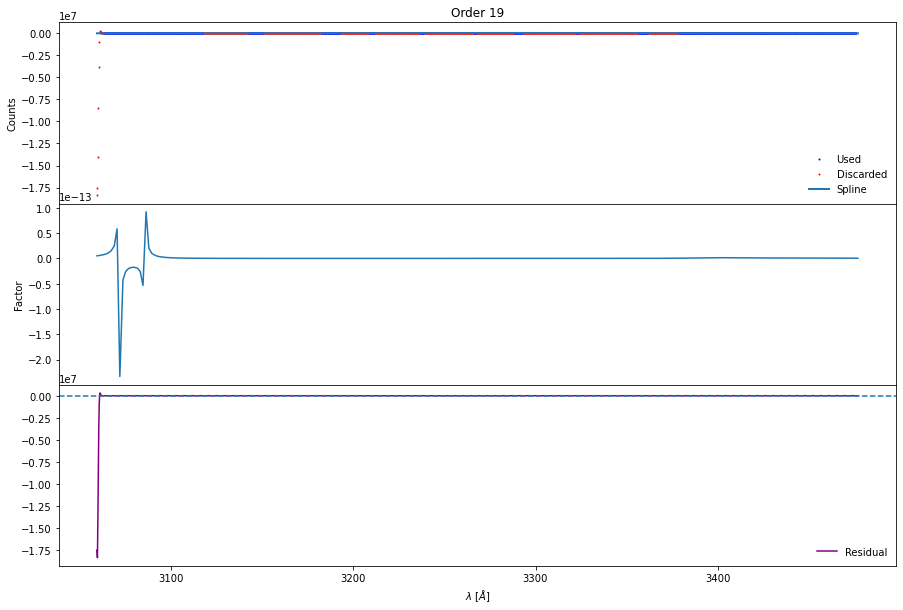

In [63]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x19[mask19][x19[mask19] < 3476], y19[mask19][x19[mask19] < 3476],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x19[np.logical_not(mask19)][x19[np.logical_not(mask19)] < 3476],
            y19[np.logical_not(mask19)][x19[np.logical_not(mask19)] < 3476],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(19)[:1726], y_est_custom19[:1726],
            lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_feige110.lda, factor19)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(19)[:1726],
            feige110.flux(19)[:1726] - y_est_custom19[:1726],
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Order 20

In [64]:
y20 = feige110.flux(20)
x20 = feige110.wavelength(20)

mask20 = (x20 > 3042.7) * (x20 < 3047.8) \
       + (x20 > 3052.7) * (x20 < 3056.4) \
       + (x20 > 3070.4) * (x20 < 3081.9) \
       + (x20 > 3122) * (x20 < 3126) \
       + (x20 > 3143.3) * (x20 < 3147.4) \
       + (x20 > 3163.29) * (x20 < 3168) \
       + (x20 > 3184.8) * (x20 < 3193.5) \
       + (x20 > 3212) * (x20 < 3218.4) \
       + (x20 > 3233.4) * (x20 < 3296)

knots20 = np.array([3045, 3054, 3075, 3124, 3145.3, 3167, 3189,
                    3215, 3240, 3266, 3290])

In [65]:
model_custom20 = get_natural_cubic_spline_model(x=x20[mask20],
                                                y=y20[mask20],
                                                minval=np.min(x20),
                                                maxval=np.max(x20),
                                                knots=knots20)
y_est_custom20 = model_custom20.predict(feige110.wavelength(20))

In [66]:
obs_flux20 = spectres(simple_feige110.lda, feige110.wavelength(20),
                      y_est_custom20, verbose=False)
factor20 = reference_flux(simple_feige110.lda)/obs_flux20

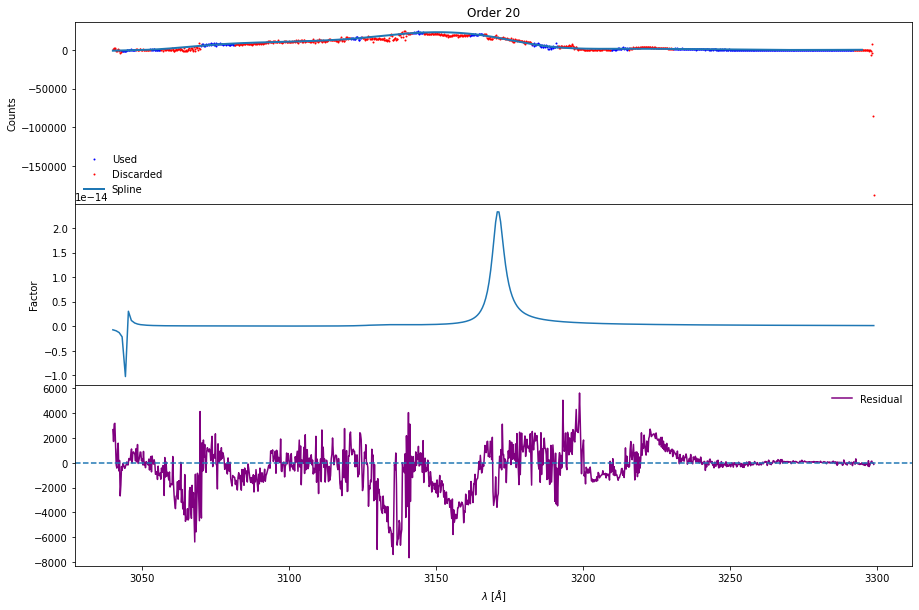

In [67]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(x20[mask20][x20[mask20] < 3303], y20[mask20][x20[mask20] < 3303],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(x20[np.logical_not(mask20)][x20[np.logical_not(mask20)] < 3303],
            y20[np.logical_not(mask20)][x20[np.logical_not(mask20)] < 3303],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(feige110.wavelength(20)[:1144], y_est_custom20[:1144], lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 20')

axs[1].plot(simple_feige110.lda, factor20)
axs[1].set_ylabel('Factor')

axs[2].plot(feige110.wavelength(20)[:1144],
            feige110.flux(20)[:1144] - y_est_custom20[:1144],
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Flux calibration

In [68]:
simple_feige110.flux[:] = y_est_custom_model

In [69]:
spline_flux = [
    y_est_custom6,
    y_est_custom7,
    y_est_custom8,
    y_est_custom9,
    y_est_custom10,
    y_est_custom11,
    y_est_custom12,
    y_est_custom13,
    y_est_custom14,
    y_est_custom15,
    y_est_custom16,
    y_est_custom17,
    y_est_custom18,
    y_est_custom19,
    y_est_custom20
]

In [70]:
for i in range(6, 21):
    feige110.flux(i)[:] =  spline_flux[i - 6]
    print('Order {:} succesful'.format(i))

Order 6 succesful
Order 7 succesful
Order 8 succesful
Order 9 succesful
Order 10 succesful
Order 11 succesful
Order 12 succesful
Order 13 succesful
Order 14 succesful
Order 15 succesful
Order 16 succesful
Order 17 succesful
Order 18 succesful
Order 19 succesful
Order 20 succesful


In [71]:
flux_calibrate_multispec(J0136, feige110, simple_feige110)

Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9
Flux calibrating order : 10
Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12
Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' 

In [72]:
#J0136.to_fits("/home/benjamin/Documents/analogs/specs/fits/j0136-0037.fits")

In [107]:
dict_orders = {6:[9500,10375],
               7:[8150,9470],
               8:[7123,8270],
               9:[6535,7205],
               10:[5900,6590],
               11:[5230,5983],
               12:[4830,5470],
               13:[4495,5030],
               14:[4185,4665],
               15:[3925,4360],
               16:[3725,4030]}

<ErrorbarContainer object of 3 artists>

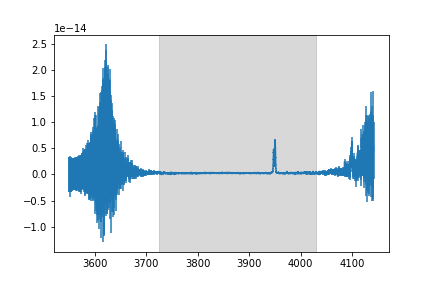

In [113]:
%matplotlib widget
i=16
plt.axvspan(dict_orders[i][0], dict_orders[i][1], color='gray', alpha=0.3)
plt.errorbar(J0136.wavelength(i), J0136.flux(i), J0136.noise(i))